In [3]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


<Figure size 1000x500 with 0 Axes>

<AxesSubplot:>

Text(0.5, 1.0, 'Original V Histogram')

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.000000

(0.0, 256.0)

...

Text(0.5, 1.0, 'Original Image')

(-0.5, 1279.5, 719.5, -0.5)

<AxesSubplot:>

Text(0.5, 1.0, 'Equalized Image')

(-0.5, 1279.5, 719.5, -0.5)

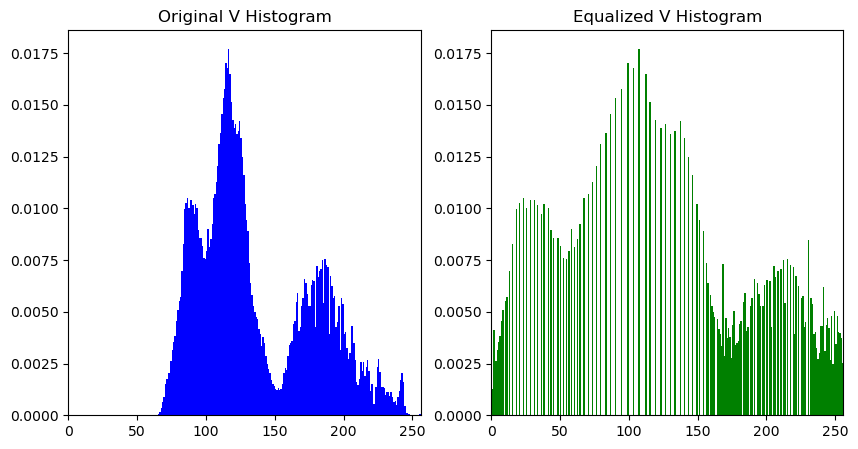

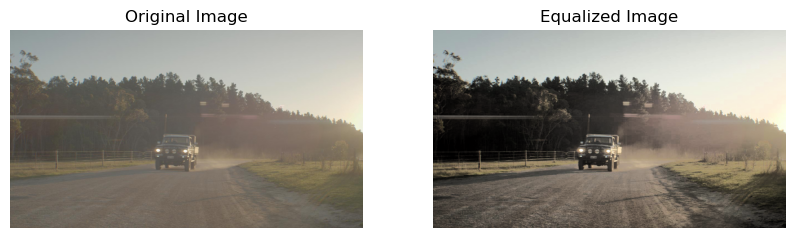

In [10]:
import cv2 as cv 
import matplotlib.pyplot as plt

# Loading the colored image using OpenCV
image = cv.imread('coloured_low_contrast_8.jpg')

# Converting the image to HSV color space
hsv_image = cv.cvtColor(image, cv.COLOR_BGR2HSV)

# Spliting the HSV image into its components
h_channel, s_channel, v_channel = cv.split(hsv_image)

# Applying histogram equalization to the V channel
v_channel_equalized = cv.equalizeHist(v_channel)

# Merging the equalized V channel with the H and S channels
equalized_hsv_image = cv.merge((h_channel, s_channel, v_channel_equalized))

# Converting the HSV image with equalized V back to BGR color space
equalized_bgr_image = cv.cvtColor(equalized_hsv_image, cv.COLOR_HSV2BGR)

# Plotting the histogram of the original V channel
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original V Histogram')
plt.hist(v_channel.ravel(), bins=256, range=(0, 256), density=True, color='blue')
plt.xlim(0, 256)

# Plotting the histogram of the equalized V channel
plt.subplot(1, 2, 2)
plt.title('Equalized V Histogram')
plt.hist(v_channel_equalized.ravel(), bins=256, range=(0, 256), density=True, color='green')
plt.xlim(0, 256)

# Displaying the original and equalized images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Equalized Image')
plt.imshow(cv.cvtColor(equalized_bgr_image, cv.COLOR_BGR2RGB))
plt.axis('off')

plt.show()
